In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [12]:
data = np.load("windows_500_50.npz", allow_pickle=True)

X = data["X"]
y = data["y_env"]

print("Dataset shape:", X.shape)

Dataset shape: (3297, 500)


In [13]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)

print("Classes:", encoder.classes_)

Classes: ['bridge' 'forest' 'garden' 'lake' 'river']


In [14]:
X = X[..., np.newaxis]

print(X.shape)

(3297, 500, 1)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(2472, 500, 1)
(825, 500, 1)


In [6]:
X = X[...,np.newaxis]

In [16]:
def build_cnn(input_shape, num_classes):

    model = models.Sequential([

        layers.Conv1D(32, 5, padding="same", activation="relu", input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling1D(2),

        layers.Conv1D(64, 5, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling1D(2),

        layers.Conv1D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling1D(2),

        layers.Conv1D(256, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),

        layers.GlobalAveragePooling1D(),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),

        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [8]:
model = models.Sequential([

layers.Conv1D(32,5,activation='relu',input_shape=X_train.shape[1:]),
layers.MaxPooling1D(2),

layers.Conv1D(64,5,activation='relu'),
layers.MaxPooling1D(2),

layers.Conv1D(128,3,activation='relu'),

layers.GlobalAveragePooling1D(),

layers.Dense(64,activation='relu'),
layers.Dropout(0.3),

layers.Dense(len(np.unique(y)),activation='softmax')

])

C:\Users\Lenovo\miniconda3\envs\iot_ml\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model = build_cnn(X_train.shape[1:], len(np.unique(y)))

model.summary()

C:\Users\Lenovo\miniconda3\envs\iot_ml\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)                    │ (None, 500, 32)             │             192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 500, 32)             │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 250, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_4 (Conv1D)                    │ (None, 250, 64)             │          10,304 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 250, 64)             │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_3 (MaxPooling1D)       │ (None, 125, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_5 (Conv1D)                    │ (None, 125, 128)            │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 125, 128)            │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_4 (MaxPooling1D)       │ (None, 62, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_6 (Conv1D)                    │ (None, 62, 256)             │          98,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 62, 256)             │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d_1           │ (None, 256)                 │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 169,221 (661.02 KB)

 Trainable params: 168,261 (657.27 KB)

 Non-trainable params: 960 (3.75 KB)

In [18]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5
)

In [19]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, lr_reduce]
)

Epoch 1/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - accuracy: 0.5243 - loss: 1.1590 - val_accuracy: 0.2400 - val_loss: 2.1672 - learning_rate: 0.0010
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.6270 - loss: 0.9145 - val_accuracy: 0.2400 - val_loss: 3.5076 - learning_rate: 0.0010
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.6683 - loss: 0.8477 - val_accuracy: 0.2400 - val_loss: 4.4425 - learning_rate: 0.0010
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.7051 - loss: 0.7332 - val_accuracy: 0.2400 - val_loss: 5.3872 - learning_rate: 0.0010
Epoch 5/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.7108 - loss: 0.7115 - val_accuracy: 0.2412 - val_loss: 4.7212 - learning_rate: 0.0010
Epoch 6/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.7500 - loss: 0.6144 - val_accuracy: 0.2267 - val_loss: 4.6332 - learning_rate: 0.0010
Epoch 7/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.7811 - loss: 0.5481 - val_acc

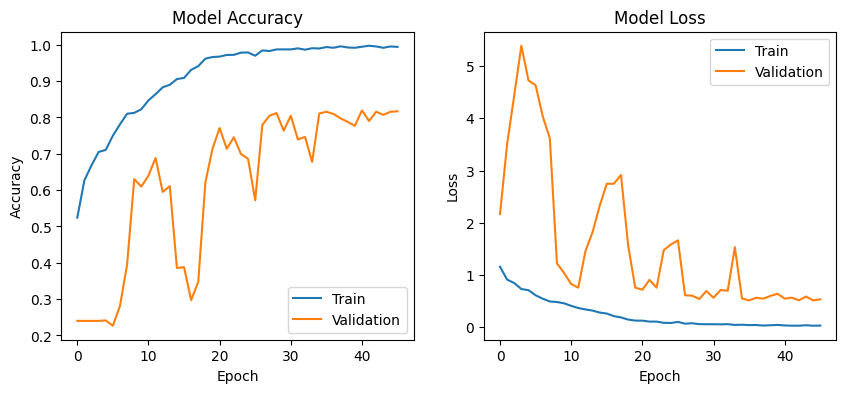

In [20]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

In [21]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8158 - loss: 0.5156
Test Accuracy: 0.8157575726509094


In [22]:
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


In [23]:
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

              precision    recall  f1-score   support

      bridge       0.86      0.82      0.84       220
      forest       0.86      0.88      0.87       198
      garden       0.64      0.56      0.60       103
        lake       0.90      0.86      0.88       168
       river       0.72      0.86      0.78       136

    accuracy                           0.82       825
   macro avg       0.80      0.80      0.79       825
weighted avg       0.82      0.82      0.82       825



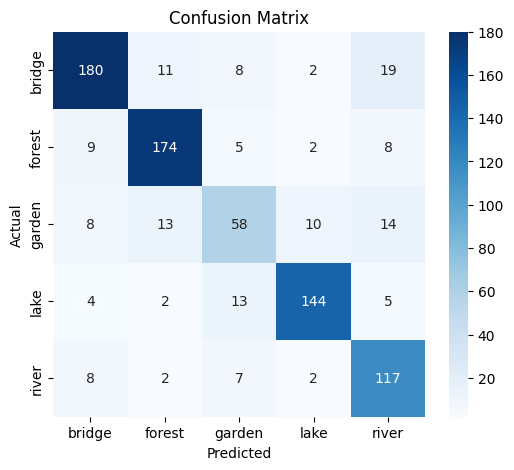

In [24]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_,
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [25]:
model.save("cnn_environment_model.h5")